In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
tf.random.set_seed(2382)

2024-11-14 10:52:25.673749: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-14 10:52:25.676984: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-14 10:52:25.687264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731610345.704466  360712 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731610345.709192  360712 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-14 10:52:25.727380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

# 0. Load the data

In [2]:
Dtrain, Dtest = mnist.load_data()
Xtrain, ytrain = Dtrain
Xtest, ytest = Dtest

# 1. Image normalization, output encoding

In [3]:
Xtrain_norm = Xtrain / 255.0
Xtest_norm = Xtest / 255.0

ytrain_ohe = tf.keras.utils.to_categorical(ytrain)
ytest_ohe = tf.keras.utils.to_categorical(ytest)

# 2. Convolutional neural network

In [4]:
model = ...

2024-11-14 10:52:27.952116: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss=...,
              optimizer='adam',
              metrics=[...])

# 3. Train the model

In [6]:
trainhist = model.fit(Xtrain, ytrain_ohe, 
                batch_size=..., 
                epochs=..., 
                validation_split=...)

Epoch 1/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.7854 - loss: 2.7974 - val_accuracy: 0.9665 - val_loss: 0.1281
Epoch 2/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9684 - loss: 0.1210 - val_accuracy: 0.9718 - val_loss: 0.1044
Epoch 3/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9808 - loss: 0.0666 - val_accuracy: 0.9770 - val_loss: 0.0866
Epoch 4/4
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9853 - loss: 0.0499 - val_accuracy: 0.9785 - val_loss: 0.0827


### Evolution of the model during training

Text(0.5, 0, 'epochs')

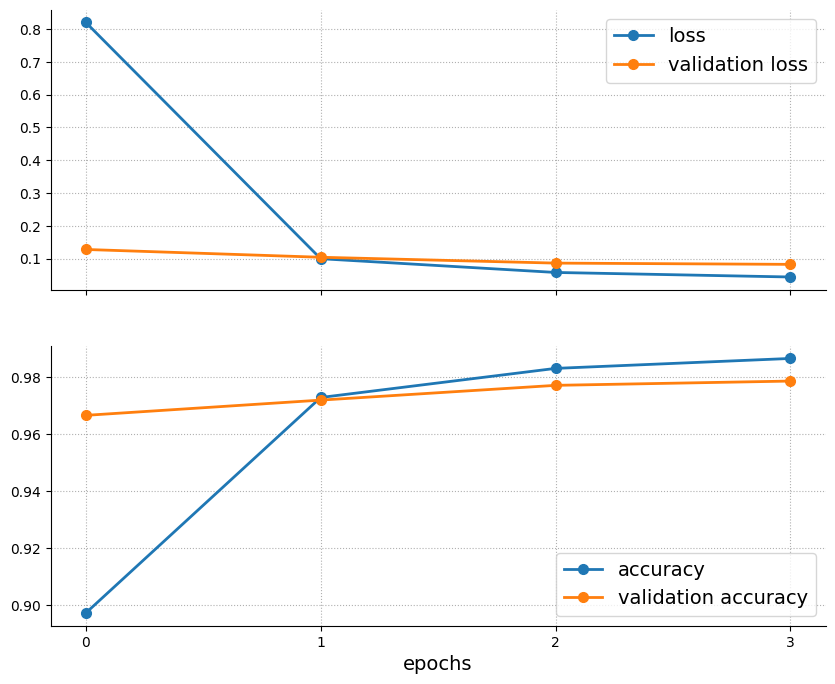

In [7]:
fig, axs = plt.subplots(figsize=(10,8),nrows=2,sharex=True)

ax=axs[0]
ax.plot(trainhist.history['loss'],'.-',linewidth=2,markersize=14,label='loss')
ax.plot(trainhist.history['val_loss'],'.-',linewidth=2,markersize=14,label='validation loss')
ax.grid(linestyle=':')
ax.legend(fontsize=14)
ax.spines[['top','right']].set_visible(False)

ax = axs[1]
ax.plot(trainhist.history['accuracy'],'.-',linewidth=2,markersize=14,label='accuracy')
ax.plot(trainhist.history['val_accuracy'],'.-',linewidth=2,markersize=14,label='validation accuracy')
ax.grid(linestyle=':')
ax.legend(fontsize=14)
ax.spines[['top','right']].set_visible(False)

ax.set_xticks(range(trainhist.params['epochs']))
ax.set_xlabel('epochs',fontsize=14)

# 4. Evaluate on the test data

In [9]:
testresult = model.evaluate(Xtest,ytest_ohe)

# model.metrics_names lists the variables returned by model.evaluate
model.metrics_names, testresult

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9759 - loss: 0.0993


(['loss', 'compile_metrics'], [0.08078645914793015, 0.98089998960495])